In [59]:
import sys
from pathlib import Path
import pinocchio as pin

ROOT = Path().resolve().parents[0]  # project root
sys.path.insert(0, str(ROOT))

from src.case1_trainer import build_fno_dataset, make_dataloaders, load_trained_model
from src.case2_trainer import build_multistep_fno_dataset, make_multistep_dataloaders, load_trained_multistep_model
from src.predictors import make_numerical_predictor, make_learned_multistep_predictor, make_learned_single_step_predictor
from src.case1_fno import PredictorFNO
from src.case2_fno import MultistepPredictorFNO
from src.config import make_config
from src.simulate import make_simulator, build_robot, make_reference, simulate_with_predictor, sample_initial_state

import numpy as np
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
data_singlestep = np.load("dataset/singlestep_predictor_dataset_small.npz")

X, Y = build_fno_dataset(data_singlestep)
_, _, stats_single = make_dataloaders(
    X, Y,
    batch_size=128,
    val_fraction=0.2,
    seed=0,
)

model_singlestep = PredictorFNO(
    hidden_size=64,
    num_layers=4,
    modes=16,
    input_channel=X.shape[2],
    fno_output_channel=128,
    output_dim=Y.shape[1],
)
model_singlestep, _ = load_trained_model(
    model_singlestep,
    "models/singlestep_predictor_fno.pt",
    device,
)

data_multistep = np.load("dataset/multistep_predictor_dataset_small.npz")

X, Y = build_multistep_fno_dataset(data_multistep)
_, _, stats_multi = make_multistep_dataloaders(
    X, Y,
    batch_size=128,
    val_fraction=0.2,
    seed=0,
)

model_multistep= MultistepPredictorFNO(
    hidden_size=128,
    num_layers=4,
    modes=32,
    input_channel=X.shape[2],
    fno_output_channel=128,
    output_dim=Y.shape[2],
    output_horizon=Y.shape[1],
)

model_multistep, _ = load_trained_multistep_model(
    model_multistep,
    "models/multistep_predictor_fno.pt",
    device,
)

cfg = make_config(
    urdf="xarm6.urdf",
    dt=0.001,
    T=20.0,
    D=0.2,
    Ts=0.05,
    predictor_tolerance=1e-8,
    max_picard_iters=50,
    inner_predictor_discretization_steps=4,
)

robot = build_robot(cfg["urdf"])
ref = make_reference(robot, cfg)
sim = make_simulator(robot, cfg, ref)

num_predictor = make_numerical_predictor(sim, cfg)
fno_predictor_multi = make_learned_multistep_predictor(model_multistep, stats_multi, device, robot, cfg)
fno_predictor_single = make_learned_single_step_predictor(model_singlestep, stats_single, device)

In [48]:
rng = np.random.default_rng(0)

# initial state
q0, v0 = sample_initial_state(robot, rng)

# copy RNG so both simulations get identical sampling/noise
rng_num = np.random.default_rng(0)
rng_single = np.random.default_rng(0)
rng_multi = np.random.default_rng(0)

max_h = 0.1
min_h = 0.02

out_num = simulate_with_predictor(
    sim,
    robot,
    ref,
    cfg,
    num_predictor,
    q0=q0,
    v0=v0,
    q_meas_noise_std=0.005,
    v_meas_noise_std=0.005,
    rng=rng_num,
    random_sampling=True,
    max_sample_h=max_h,
    min_sample_h=min_h,
)

out_single = simulate_with_predictor(
    sim,
    robot,
    ref,
    cfg,
    fno_predictor_single,
    q0=q0,
    v0=v0,
    q_meas_noise_std=0.005,
    v_meas_noise_std=0.005,
    rng=rng_single,
    random_sampling=True,
    max_sample_h=max_h,
    min_sample_h=min_h,
)

out_multi = simulate_with_predictor(
    sim,
    robot,
    ref,
    cfg,
    fno_predictor_multi,
    q0=q0,
    v0=v0,
    q_meas_noise_std=0.005,
    v_meas_noise_std=0.005,
    rng=rng_multi,
    random_sampling=False,
)

In [49]:
def plot_predictor_comparison_first_steps(out_num, out_fno, n_steps=20000):
    t = out_num["t"][:n_steps]

    # sample times (use learned predictor rollout)
    sample_flag = out_fno["sample_flag"][:n_steps]
    t_samples = t[sample_flag]

    # closed-loop tracking errors
    err_num = np.linalg.norm(out_num["q"][:n_steps] - out_num["q_des_now"][:n_steps], axis=1)
    err_fno = np.linalg.norm(out_fno["q"][:n_steps] - out_fno["q_des_now"][:n_steps], axis=1)

    plt.figure(figsize=(8, 4))

    plt.plot(t, err_num, label="numerical predictor")
    plt.plot(t, err_fno, label="learned predictor")

    # scatter sample times using learned predictor
    plt.scatter(
        t_samples,
        err_fno[sample_flag],
        color="black",
        s=20,
        label="sample times",
        zorder=3,
    )

    plt.xlabel("time [s]")
    plt.ylabel(r"$\|q(t)-q_d(t)\|$")
    plt.title(f"Closed-loop tracking error (first {n_steps} steps)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # internal predictor-state mismatch
    pred_gap = np.linalg.norm(out_num["qz"][:n_steps] - out_fno["qz"][:n_steps], axis=1)

    p)lt.figure(figsize=(8, 4))

    plt.plot(t, pred_gap)

    plt.scatter(
        t_samples,
        pred_gap[sample_flag],
        color="black",
        s=20,
        label="sample times",
        zorder=3,
    )

    plt.xlabel("time [s]")
    plt.ylabel(r"$\|Z_{\rm num}(t)-Z_{\rm learned}(t)\|$")
    plt.title(f"Internal predictor-state mismatch (first {n_steps} steps)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

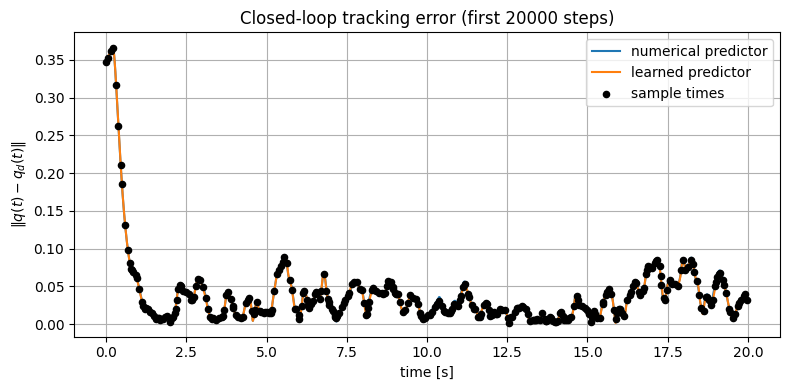

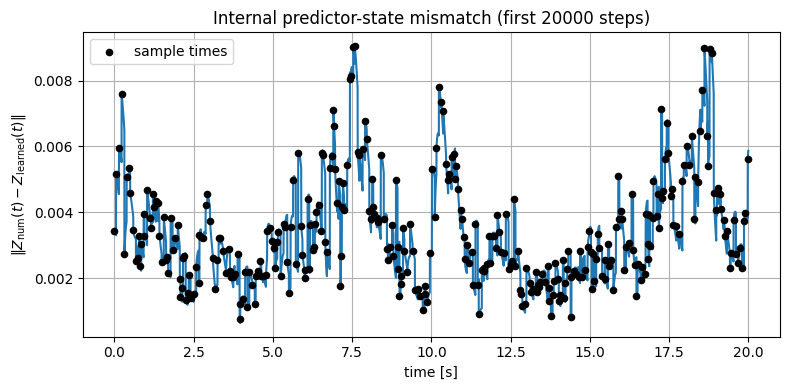

In [50]:
plot_predictor_comparison_first_steps(out_num, out_single)

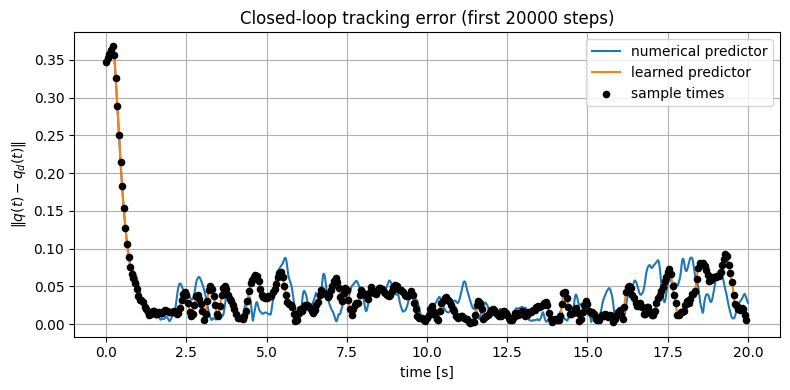

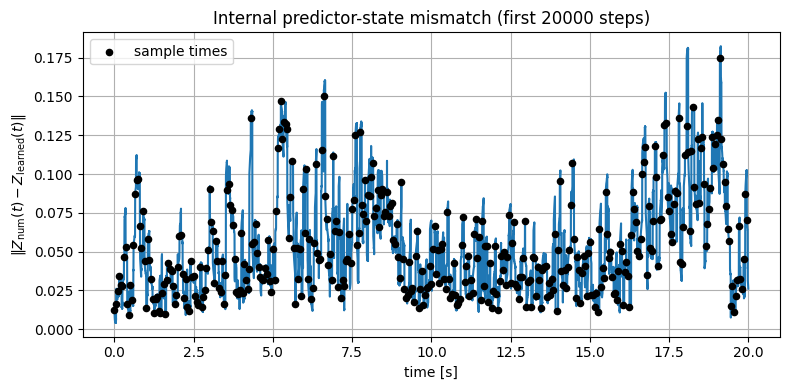

In [51]:
plot_predictor_comparison_first_steps(out_num, out_multi)

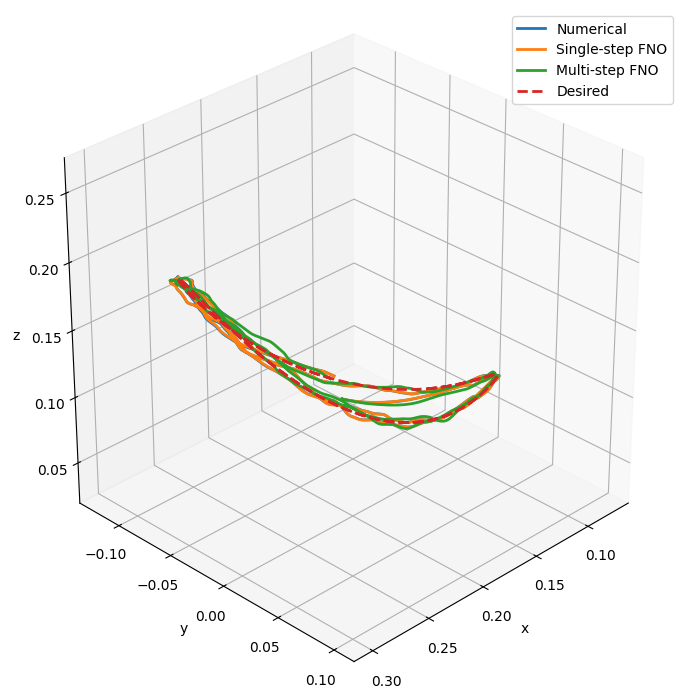

In [72]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

ee_num = get_ee_xyz_traj(robot, out_num["q"])
ee_single = get_ee_xyz_traj(robot, out_single["q"])
ee_multi = get_ee_xyz_traj(robot, out_multi["q"])
ee_des = get_ee_xyz_traj(robot, out_num["q_des_now"])

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# trajectories
ax.plot(*ee_num.T, label="Numerical", linewidth=2)
ax.plot(*ee_single.T, label="Single-step FNO", linewidth=2)
ax.plot(*ee_multi.T, label="Multi-step FNO", linewidth=2)
ax.plot(*ee_des.T, '--', label="Desired", linewidth=2)

# labels
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

# --- equal axis scaling (critical for true geometry) ---
all_pts = np.vstack([ee_num, ee_single, ee_multi, ee_des])
xmin, ymin, zmin = all_pts.min(axis=0)
xmax, ymax, zmax = all_pts.max(axis=0)

max_range = np.max([xmax-xmin, ymax-ymin, zmax-zmin]) / 2
mid = (all_pts.max(axis=0) + all_pts.min(axis=0)) / 2

ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

# --- good viewing angle ---
ax.view_init(elev=30, azim=45)

# optional: reduce perspective distortion
ax.set_box_aspect([1,1,1])

ax.legend()
plt.tight_layout()
plt.show()

Proper paper figure

In [277]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

def set_size(width, fraction=1, subplots=(1, 1), height_add=0):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    if width == 'thesis':
        width_pt = 426.79135
    elif width == 'beamer':
        width_pt = 307.28987
    else:
        width_pt = width

    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = height_add + fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

def compute_prediction_error(out, D, task_space=False, robot=None, frame_id=None):
    t_valid, q_future, q_pred = compute_future_true_q(out, D)
    err = np.linalg.norm(q_pred - q_future, axis=1)

    return t_valid, err

def compute_future_true_q(out, D):
    t = out["t"]
    q = out["q"]
    qz = out["qz"]

    t_future = t + D
    valid = t_future <= t[-1]

    nq = q.shape[1]
    q_future = np.zeros((valid.sum(), nq))
    for j in range(nq):
        q_future[:, j] = np.interp(t_future[valid], t, q[:, j])

    return t[valid], q_future, qz[valid]

def compute_state_tracking_error(out, ref=None):
    """
    Computes ||X(t) - X_des(t)|| where
        X(t)     = [q(t); v(t)]
        X_des(t) = [q_des(t); v_des(t)]

    Priority:
      1. use out["q_des_now"] and out["v_des_now"] if both are logged
      2. otherwise use ref["q_des"], ref["v_des"] evaluated on out["t"]
    """
    q = out["q"]
    v = out["v"]

    if "q_des_now" in out and "v_des_now" in out:
        q_des = out["q_des_now"]
        v_des = out["v_des_now"]
    elif ref is not None:
        t = out["t"]
        q_des = np.array([ref["q_des"](ti) for ti in t])
        v_des = np.array([ref["v_des"](ti) for ti in t])
    else:
        raise ValueError(
            "Need desired velocity to compute full-state tracking error. "
            "Either log out['v_des_now'] in simulate_with_predictor or pass ref with ref['v_des']."
        )

    x = np.concatenate([q, v], axis=1)
    x_des = np.concatenate([q_des, v_des], axis=1)

    return np.linalg.norm(x - x_des, axis=1)

import numpy as np

def moving_average(x, window):
    """
    Centered moving average smoothing.

    Parameters
    ----------
    x : array
        signal to smooth
    window : int
        number of samples in averaging window (must be >=1)

    Returns
    -------
    smoothed signal (same length as x)
    """
    if window <= 1:
        return x

    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")

In [280]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import matplotlib.pyplot as plt


def make_four_panel_sampling_figure(
    robot,
    out_num,
    out_single,
    out_multi,
    D,
    frame_id=None,
    use_task_space_error=True,
    figsize=(11, 8),
    schedule_window=None,
    marker_stride=1,
    t_max=None,
    tracking_joint_idx=None, ref=None, smooth_window=50
):
    label_map = {
        "Numerical": "Numerical",
        "Single-step FNO": "Case 2",
        "Multi-step FNO": "Case 1",
        "Desired": "Desired",
    }

    styles = {
        "Multi-step FNO": {
            "color": "#0072B2",
            "linestyle": "-",
            "linewidth": 1.5,
            "zorder": 2,
        },
        "Single-step FNO": {
            "color": "#D55E00",
            "linestyle": "--",
            "linewidth": 1.5,
            "zorder": 3,
        },
        "Numerical": {
            "color": "#009E73",
            "linestyle": ":",
            "linewidth": 1.5,
            "zorder": 4,
        },
        "Desired": {
            "color": "#111111",
            "linestyle": "-.",
            "linewidth": 1.5,
            "zorder": 1,
        },
    }

    outputs = {
        "Numerical": out_num,
        "Single-step FNO": out_single,
        "Multi-step FNO": out_multi,
    }

    markers = {
        "Numerical": "o",
        "Single-step FNO": "s",
        "Multi-step FNO": "^",
    }

    def mask_t(t):
        if t_max is None:
            return np.ones_like(t, dtype=bool)
        return t <= t_max

    if tracking_joint_idx is None:
        tracking_joint_idx = out_num["q"].shape[1] - 1

    t0 = out_num["t"][0]
    tf = out_num["t"][-1] if t_max is None else min(t_max, out_num["t"][-1])

    if schedule_window is None:
        T_show = min(1.0, tf - t0)
        schedule_window = (t0, t0 + T_show)

    w0, w1 = schedule_window
    if t_max is not None:
        w1 = min(w1, t_max)

    # use the same window for the prediction panel and inset zooms
    pred_w0, pred_w1 = w0, w1

    fig, axs = plt.subplots(2, 2, figsize=figsize)
    ax_joint, ax_sched = axs[0, 0], axs[0, 1]
    ax_track, ax_pred = axs[1, 0], axs[1, 1]

    # -------------------------------------------------
    # (a) Last-joint tracking
    # -------------------------------------------------
    # -------------------------------------------------
    # (a) Last-joint tracking
    # -------------------------------------------------
    joint_styles = {
        "Multi-step FNO": {
            "color": styles["Multi-step FNO"]["color"],
            "linestyle": styles["Multi-step FNO"]["linestyle"],
            "linewidth": 1.5,
            "zorder": styles["Multi-step FNO"]["zorder"],
        },
        "Single-step FNO": {
            "color": styles["Single-step FNO"]["color"],
            "linestyle": styles["Single-step FNO"]["linestyle"],
            "linewidth": 1.5,
            "zorder": styles["Single-step FNO"]["zorder"],
        },
        "Numerical": {
            "color": styles["Numerical"]["color"],
            "linestyle": styles["Numerical"]["linestyle"],
            "linewidth": 1.5,
            "zorder": styles["Numerical"]["zorder"],
        },
        "Desired": {
            "color": styles["Desired"]["color"],
            "linestyle": styles["Desired"]["linestyle"],
            "linewidth": 1.5,
            "zorder": styles["Desired"]["zorder"],
        },
    }
    
    m_num = mask_t(out_num["t"])
    m_single = mask_t(out_single["t"])
    m_multi = mask_t(out_multi["t"])
    
    ax_joint.plot(
        out_num["t"][m_num],
        out_num["q_des_now"][m_num, tracking_joint_idx],
        label=label_map["Desired"],
        **joint_styles["Desired"],
    )
    ax_joint.plot(
        out_num["t"][m_num],
        out_num["q"][m_num, tracking_joint_idx],
        label=label_map["Numerical"],
        **joint_styles["Numerical"],
    )
    ax_joint.plot(
        out_single["t"][m_single],
        out_single["q"][m_single, tracking_joint_idx],
        label=label_map["Single-step FNO"],
        **joint_styles["Single-step FNO"],
    )
    ax_joint.plot(
        out_multi["t"][m_multi],
        out_multi["q"][m_multi, tracking_joint_idx],
        label=label_map["Multi-step FNO"],
        **joint_styles["Multi-step FNO"],
    )
    
    ax_joint.set_title(f"(a) Joint {tracking_joint_idx} tracking")
    ax_joint.set_ylabel("Angle [rad]")
    ax_joint.grid(True, alpha=0.22)
    if t_max is not None:
        ax_joint.set_xlim(t0, t_max)
    
    # --- inset zoom for joint tracking ---
    axins_joint = inset_axes(
        ax_joint,
        width="38%",
        height="38%",
        bbox_to_anchor=(-0.25, -0.1, 1, 1),
        bbox_transform=ax_joint.transAxes,
        borderpad=0,
    )
    
    for name in ["Numerical", "Single-step FNO", "Multi-step FNO"]:
        out = outputs[name]
        mt = mask_t(out["t"])
        axins_joint.plot(
            out["t"][mt],
            out["q"][mt, tracking_joint_idx],
            **joint_styles[name],
        )
    
    axins_joint.plot(
        out_num["t"][m_num],
        out_num["q_des_now"][m_num, tracking_joint_idx],
        **joint_styles["Desired"],
    )
    
    # fixed inset window
    zoom_t0 = 7.0
    zoom_t1 = 8.0
    axins_joint.set_xlim(zoom_t0, zoom_t1)
    
    joint_curves = []
    for arr_t, arr_q in [
        (out_num["t"], out_num["q"][:, tracking_joint_idx]),
        (out_single["t"], out_single["q"][:, tracking_joint_idx]),
        (out_multi["t"], out_multi["q"][:, tracking_joint_idx]),
        (out_num["t"], out_num["q_des_now"][:, tracking_joint_idx]),
    ]:
        m = (arr_t >= zoom_t0) & (arr_t <= zoom_t1)
        if np.any(m):
            joint_curves.append(arr_q[m])
    
    if joint_curves:
        y_zoom = np.concatenate(joint_curves)
        y_min, y_max = np.min(y_zoom), np.max(y_zoom)
        pad = max(1e-6, 0.1 * (y_max - y_min))
        axins_joint.set_ylim(y_min - pad, y_max + pad)
    
    axins_joint.set_xticks([])
    axins_joint.set_yticks([])
    ax_joint.indicate_inset_zoom(axins_joint, edgecolor="0.4", linewidth=0.8)

    # -------------------------------------------------
    # (b) Measurement schedule
    # -------------------------------------------------
    ax_sched.set_title("(b) Measurement schedule")

    row_y = {
        "Numerical": 2.0,
        "Multi-step FNO": 1.0,
        "Single-step FNO": 0.0,
    }

    schedule_plot_order = ["Multi-step FNO", "Single-step FNO", "Numerical"]

    for name in schedule_plot_order:
        out = outputs[name]
        y = row_y[name]
        sample_idx = np.where(out["sample_flag"])[0]
        sample_t = out["t"][sample_idx]

        mask = (sample_t >= w0) & (sample_t <= w1)
        sample_t = sample_t[mask][::marker_stride]

        ax_sched.hlines(y, w0, w1, color="0.86", linewidth=1.2, zorder=1)

        if len(sample_t) > 0:
            ax_sched.vlines(
                sample_t,
                y - 0.18,
                y + 0.18,
                color=styles[name]["color"],
                linewidth=1.8,
                zorder=styles[name]["zorder"],
            )
            ax_sched.plot(
                sample_t,
                y * np.ones_like(sample_t),
                linestyle="None",
                marker=markers[name],
                markersize=4.2,
                markerfacecolor="white",
                markeredgecolor=styles[name]["color"],
                markeredgewidth=1.0,
                zorder=styles[name]["zorder"] + 0.1,
            )

    ax_sched.set_yticks([2.0, 1.0, 0.0])
    ax_sched.set_yticklabels(["Numerical", "Case 1", "Case 2"])
    ax_sched.set_xlim(w0, w1)
    ax_sched.set_ylim(-0.5, 2.5)
    ax_sched.grid(True, axis="x", alpha=0.18)

    for spine in ["top", "right", "left"]:
        ax_sched.spines[spine].set_visible(False)

    # -------------------------------------------------
    # (c) Tracking error norm
    # -------------------------------------------------
    track_plot_order = ["Multi-step FNO", "Single-step FNO", "Numerical"]
    track_errs = {}
    
    for name in track_plot_order:
        out = outputs[name]
    
        err = compute_state_tracking_error(out, ref=ref)
        err_smooth = moving_average(err, smooth_window)
    
        track_errs[name] = err_smooth
        mt = mask_t(out["t"])
    
        ax_track.plot(
            out["t"][mt],
            err_smooth[mt],
            label=label_map[name],
            **styles[name],
        )
    
    ax_track.set_title("(c) State tracking error")
    ax_track.set_xlabel("Time [s]")
    ax_track.set_ylabel(r"$|X(t)-X_{\mathrm{des}}(t)|$")  
    ax_track.grid(True, alpha=0.22)
    if t_max is not None:
        ax_track.set_xlim(t0, t_max)
    
    # --- inset zoom for tracking error ---
    axins_track = inset_axes(ax_track, width="38%", height="38%", loc="upper right")
    
    zoom_t0 = 7
    zoom_t1 = 8
    
    for name in ["Numerical", "Single-step FNO", "Multi-step FNO"]:
        out = outputs[name]
        mt = mask_t(out["t"])
        axins_track.plot(
            out["t"][mt],
            track_errs[name][mt],
            **styles[name],
        )
    
    axins_track.set_xlim(zoom_t0, zoom_t1)
    
    err_zoom = []
    for name in ["Numerical", "Single-step FNO", "Multi-step FNO"]:
        out = outputs[name]
        m = (out["t"] >= zoom_t0) & (out["t"] <= zoom_t1)
        if np.any(m):
            err_zoom.append(track_errs[name][m])
    
    if err_zoom:
        e_zoom = np.concatenate(err_zoom)
        e_min, e_max = np.min(e_zoom), np.max(e_zoom)
        pad = max(1e-8, 0.1 * (e_max - e_min))
        axins_track.set_ylim(e_min - pad, e_max + pad)
    
    axins_track.set_xticks([])
    axins_track.set_yticks([])
    ax_track.indicate_inset_zoom(axins_track, edgecolor="0.4", linewidth=0.8)
    # -------------------------------------------------
    # (d) Prediction error norm
    # -------------------------------------------------
    pred_plot_order = ["Multi-step FNO", "Single-step FNO", "Numerical"]
    
    pred_styles = {
        "Multi-step FNO": {
            "color": "#0072B2",
            "linestyle": "-",
            "linewidth": 1,
            "zorder": 1,   # lowest
        },
        "Single-step FNO": {
            "color": "#D55E00",
            "linestyle": "--",
            "linewidth": 1,
            "zorder": 3,
        },
        "Numerical": {
            "color": "#009E73",
            "linestyle": ":",
            "linewidth": 1,
            "zorder": 4,
        },
    }
    
    ymax = 0
    
    for name in pred_plot_order:
        out = outputs[name]
    
        t_valid, pred_err = compute_prediction_error(
            out,
            D=D,
            robot=robot,
            frame_id=frame_id,
        )
    
        mask_pred = (t_valid >= pred_w0) & (t_valid <= pred_w1)
        t_plot = t_valid[mask_pred]
        e_plot = pred_err[mask_pred]
    
        ymax = max(ymax, np.max(e_plot))
    
        ax_pred.plot(
            t_plot,
            e_plot,
            label=label_map[name],
            **pred_styles[name],
        )
    
    ax_pred.set_title("(d) Prediction error")
    ax_pred.set_xlabel("Time [s]")
    
    ax_pred.set_ylabel(
        r"$|\hat{Z}(t) - X(t{+}D)|$"
    )
    
    ax_pred.set_xlim(pred_w0, pred_w1)
    ax_pred.set_ylim(0, ymax * 1.05)
    
    ax_pred.grid(True, alpha=0.22)

    for ax in [ax_joint, ax_track, ax_pred]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    handles, labels = ax_joint.get_legend_handles_labels()
    
    legend_order = ["Desired", "Numerical", "Case 1", "Case 2"]
    
    ordered_handles = []
    for name in legend_order:
        idx = labels.index(name)
        ordered_handles.append(handles[idx])
    
    fig.legend(
        ordered_handles,
        legend_order,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=4,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    return fig

/tmp/ipykernel_472212/644503471.py:411: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


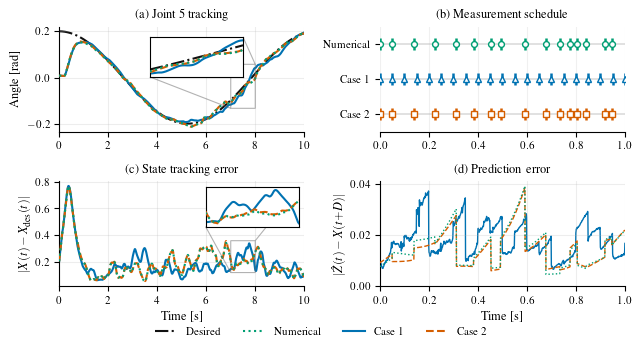

In [281]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "mathtext.fontset": "cm",

    "font.size": 9,          # base size
    "axes.labelsize": 9,
    "axes.titlesize": 9,

    "legend.fontsize": 8,

    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

fig = make_four_panel_sampling_figure(
    robot,
    out_num,
    out_single,
    out_multi,
    D=cfg["D"],
    use_task_space_error=True,
    tracking_joint_idx=robot["nq"] - 1,
    schedule_window=(0.0, 1),
    t_max=10.0,
    figsize=set_size(469, fraction=1, subplots=(2, 2), height_add=-0.6), ref=ref, smooth_window=250
)
plt.savefig("mainfig.pdf", dpi=300)
plt.show()
